In [4]:
# Environment Setup
from pathlib import Path
import sys
import matplotlib.pyplot as plt


def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loading import load_csv_files, show_basic_dataset_info, build_image_path, open_image

In [5]:
# Loading the dataset
train_df, test_df = load_csv_files()
show_basic_dataset_info(train_df, test_df)

print("\nFirst 5 train rows:")
display(train_df[["Id", "Category"]].head())

print("\nFirst 5 test rows:")
display(test_df[["Id"]].head())

Train shape: (17000, 2)
Test shape: (3000, 1)
Train columns: ['Id', 'Category']
Test columns: ['Id']
Train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Train label counts:
 Category
0    1700
1    1700
2    1700
3    1700
4    1700
5    1700
6    1700
7    1700
8    1700
9    1700
Name: count, dtype: int64

First 5 train rows:


,Id,Category
0,7168,6
1,9876,3
2,78117,6
3,9626,1
4,29492,3



First 5 test rows:


,Id
0,56604
1,29396
2,43803
3,12313
4,10341


Sample image path: /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/train/train/6/7168.png
Sample label: 6
Image mode: L
Image size: (32, 32)


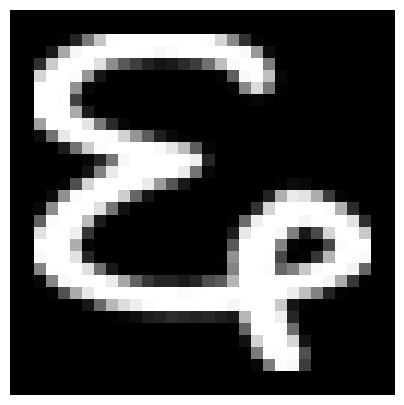

In [6]:
# Inspecting one sample image
sample_id = int(train_df.loc[0, "Id"])
sample_label = int(train_df.loc[0, "Category"])
sample_path = build_image_path(sample_id, split="train", label=sample_label)
print("Sample image path:", sample_path)
print("Sample label:", sample_label)

img = open_image(sample_path)
print("Image mode:", img.mode)  
print("Image size:", img.size) 

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()